# SLP Dataset — Exploratory Data Analysis

This notebook explores the SLP2022 (danaLab) dataset used for the vision-spatial modality of ApneaSense.

## Objectives
- Understand the dataset structure: subjects, modalities, classes, cover conditions
- Analyse class and condition distributions
- Visualise sample images across modalities, classes, and cover conditions
- Inspect image properties (size, value ranges)
- Summarise key findings to inform encoder design

## Imports

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image
import scipy.io as sio
import warnings
warnings.filterwarnings('ignore')

## Paths

In [14]:
DATASET_ROOT = Path(r"C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\Dataset\SLP2022\SLP\danaLab")
CSV_PATH = DATASET_ROOT / "posture_labels_all_modalities.csv"

print("Dataset root exists:", DATASET_ROOT.exists())
print("CSV exists:", CSV_PATH.exists())

Dataset root exists: True
CSV exists: True


## 1. Load Dataset CSV

In [15]:
df = pd.read_csv(CSV_PATH)

# Normalise modality names to lowercase for consistent filtering
df['modality'] = df['modality'].str.lower()

print("Shape:", df.shape)
df.head()

Shape: (55080, 8)


,subject_id,modality,condition,image_index,image_path,label,label_id,source
0,1,rgb,uncover,1,00001/RGB/uncover/image_000001.png,supine,0,inferred_ordering
1,1,rgb,uncover,2,00001/RGB/uncover/image_000002.png,supine,0,inferred_ordering
2,1,rgb,uncover,3,00001/RGB/uncover/image_000003.png,supine,0,inferred_ordering
3,1,rgb,uncover,4,00001/RGB/uncover/image_000004.png,supine,0,inferred_ordering
4,1,rgb,uncover,5,00001/RGB/uncover/image_000005.png,supine,0,inferred_ordering


In [16]:
print("Columns:", df.columns.tolist())
print()
print(df.dtypes)

Columns: ['subject_id', 'modality', 'condition', 'image_index', 'image_path', 'label', 'label_id', 'source']

subject_id     int64
modality         str
condition        str
image_index    int64
image_path       str
label            str
label_id       int64
source           str
dtype: object


## 2. Dataset Overview

In [17]:
print("=== Dataset Overview ===")
print(f"Total samples       : {len(df)}")
print(f"Unique subjects     : {df['subject_id'].nunique()}")
print(f"Modalities          : {sorted(df['modality'].unique())}")
print(f"Posture classes     : {sorted(df['label'].unique())}")
print(f"Cover conditions    : {sorted(df['condition'].unique())}")
print(f"Samples per modality: {df.groupby('modality').size().to_dict()}")

=== Dataset Overview ===
Total samples       : 55080
Unique subjects     : 102
Modalities          : ['depth', 'ir', 'pm', 'rgb']
Posture classes     : ['left', 'right', 'supine']
Cover conditions    : ['cover1', 'cover2', 'uncover']
Samples per modality: {'depth': 13770, 'ir': 13770, 'pm': 13770, 'rgb': 13770}


## 3. Class Distribution

In [18]:
print("=== Class Distribution (all modalities) ===")
print(df['label'].value_counts().sort_index())
print()
print("=== Class Distribution per Modality ===")
print(df.groupby(['modality', 'label']).size().unstack(fill_value=0))

=== Class Distribution (all modalities) ===
label
left      18360
right     18360
supine    18360
Name: count, dtype: int64

=== Class Distribution per Modality ===
label     left  right  supine
modality                     
depth     4590   4590    4590
ir        4590   4590    4590
pm        4590   4590    4590
rgb       4590   4590    4590


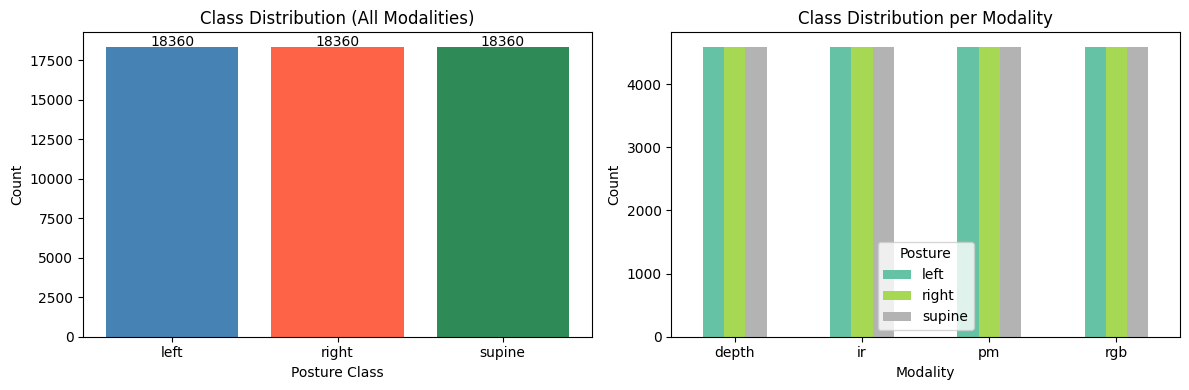

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall class distribution
class_counts = df['label'].value_counts().sort_index()
axes[0].bar(class_counts.index, class_counts.values, color=['steelblue', 'tomato', 'seagreen'])
axes[0].set_title('Class Distribution (All Modalities)')
axes[0].set_xlabel('Posture Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center')

# Class distribution per modality
modality_class = df.groupby(['modality', 'label']).size().unstack(fill_value=0)
modality_class.plot(kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('Class Distribution per Modality')
axes[1].set_xlabel('Modality')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Posture')

plt.tight_layout()
plt.show()

## 4. Cover Condition Distribution

In [20]:
print("=== Cover Condition Distribution ===")
print(df['condition'].value_counts().sort_index())
print()
print("=== Condition x Class ===")
print(df.groupby(['condition', 'label']).size().unstack(fill_value=0))

=== Cover Condition Distribution ===
condition
cover1     18360
cover2     18360
uncover    18360
Name: count, dtype: int64

=== Condition x Class ===
label      left  right  supine
condition                     
cover1     6120   6120    6120
cover2     6120   6120    6120
uncover    6120   6120    6120


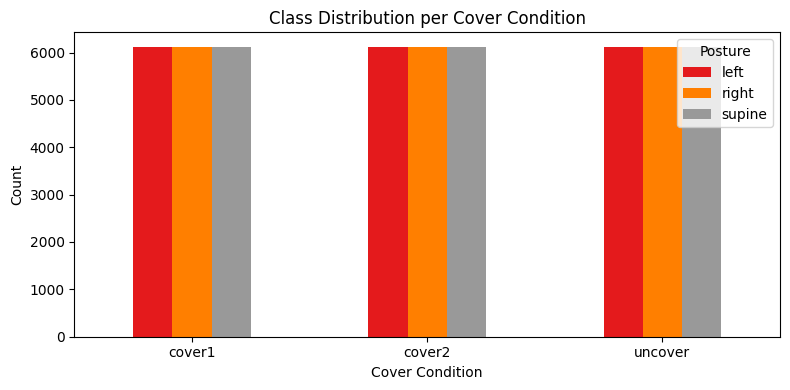

In [9]:
cond_class = df.groupby(['condition', 'label']).size().unstack(fill_value=0)

cond_class.plot(kind='bar', figsize=(8, 4), colormap='Set1')
plt.title('Class Distribution per Cover Condition')
plt.xlabel('Cover Condition')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Posture')
plt.tight_layout()
plt.show()

## 5. Subject-Level Analysis

In [21]:
# Samples per subject (for one modality)
df_depth = df[df['modality'] == 'depth']
samples_per_subject = df_depth.groupby('subject_id').size()

print("=== Samples per Subject (depth modality) ===")
print(f"Min : {samples_per_subject.min()}")
print(f"Max : {samples_per_subject.max()}")
print(f"Mean: {samples_per_subject.mean():.1f}")
print(f"Std : {samples_per_subject.std():.1f}")

=== Samples per Subject (depth modality) ===
Min : 135
Max : 135
Mean: 135.0
Std : 0.0


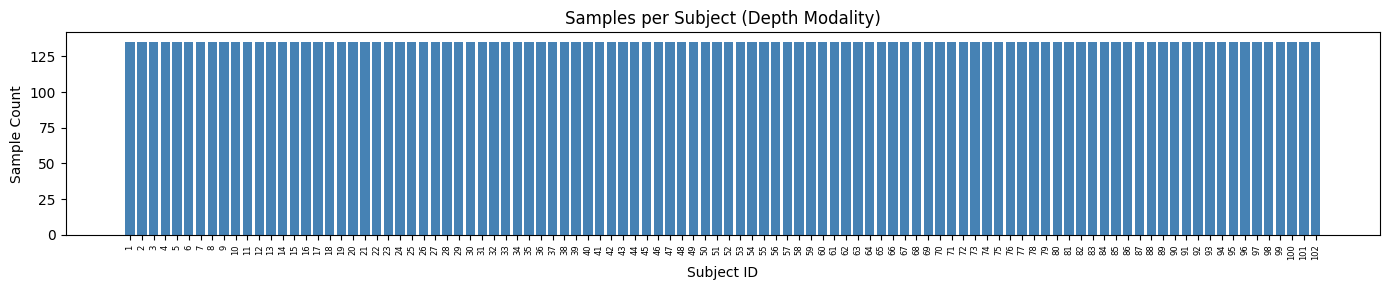

In [22]:
plt.figure(figsize=(14, 3))
plt.bar(samples_per_subject.index.astype(str), samples_per_subject.values, color='steelblue')
plt.title('Samples per Subject (Depth Modality)')
plt.xlabel('Subject ID')
plt.ylabel('Sample Count')
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()

## 6. Sample Visualisation — RGB

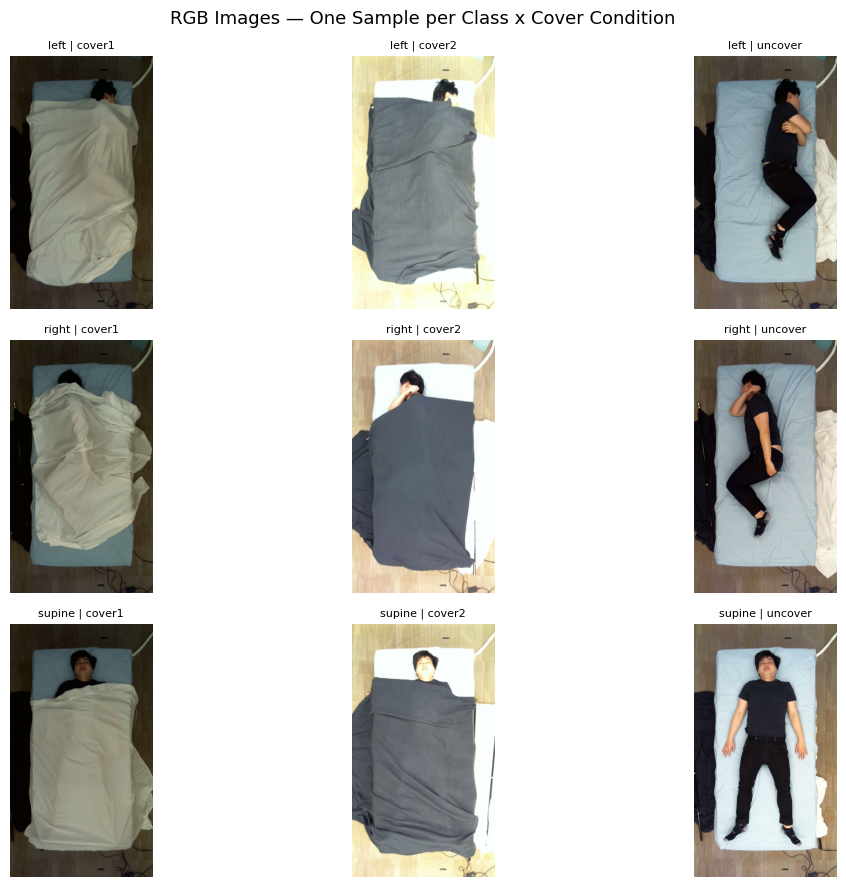

In [23]:
df_rgb = df[df['modality'] == 'rgb'].reset_index(drop=True)

classes = sorted(df_rgb['label'].unique())
conditions = sorted(df_rgb['condition'].unique())

fig, axes = plt.subplots(len(classes), len(conditions), figsize=(12, 9))
fig.suptitle('RGB Images — One Sample per Class x Cover Condition', fontsize=13)

for i, cls in enumerate(classes):
    for j, cond in enumerate(conditions):
        subset = df_rgb[(df_rgb['label'] == cls) & (df_rgb['condition'] == cond)]
        if len(subset) == 0:
            axes[i][j].axis('off')
            continue
        row = subset.iloc[0]
        img = Image.open(DATASET_ROOT / row['image_path']).convert('RGB')
        axes[i][j].imshow(img)
        axes[i][j].set_title(f'{cls} | {cond}', fontsize=8)
        axes[i][j].axis('off')

plt.tight_layout()
plt.show()

## 7. Sample Visualisation — Depth

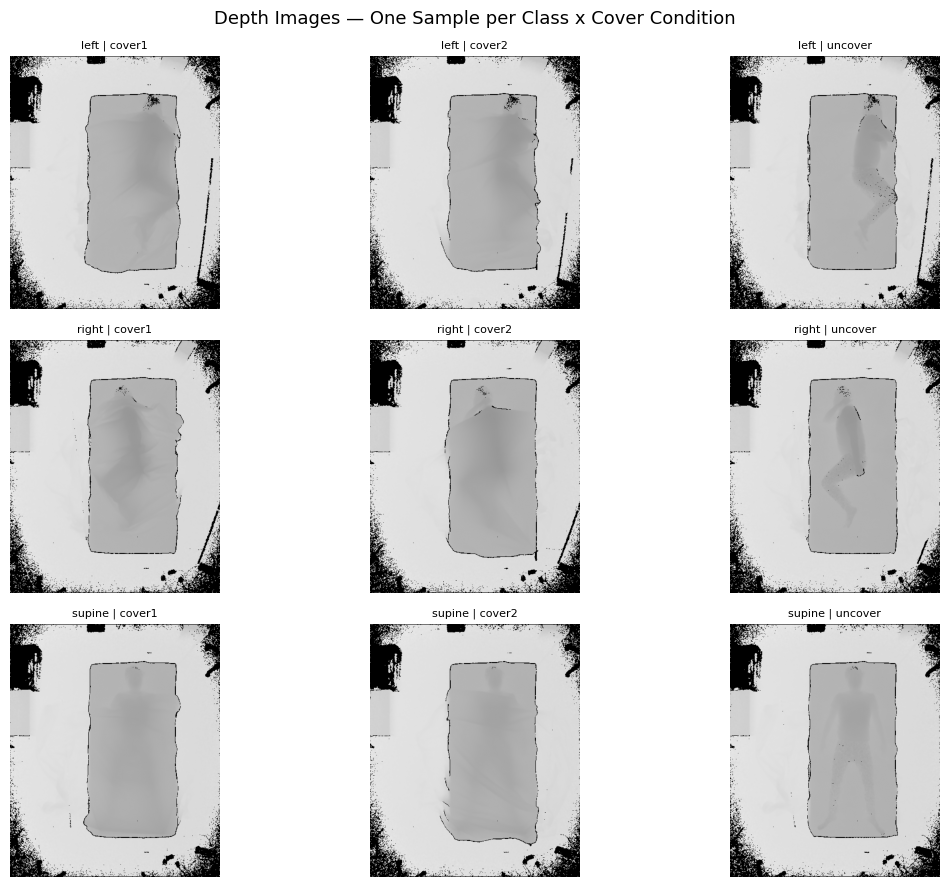

In [24]:
df_depth = df[df['modality'] == 'depth'].reset_index(drop=True)

fig, axes = plt.subplots(len(classes), len(conditions), figsize=(12, 9))
fig.suptitle('Depth Images — One Sample per Class x Cover Condition', fontsize=13)

for i, cls in enumerate(classes):
    for j, cond in enumerate(conditions):
        subset = df_depth[(df_depth['label'] == cls) & (df_depth['condition'] == cond)]
        if len(subset) == 0:
            axes[i][j].axis('off')
            continue
        row = subset.iloc[0]
        img = Image.open(DATASET_ROOT / row['image_path']).convert('L')
        axes[i][j].imshow(img, cmap='gray')
        axes[i][j].set_title(f'{cls} | {cond}', fontsize=8)
        axes[i][j].axis('off')

plt.tight_layout()
plt.show()

## 8. Side-by-Side: RGB vs Depth (Same Subject, Same Pose)

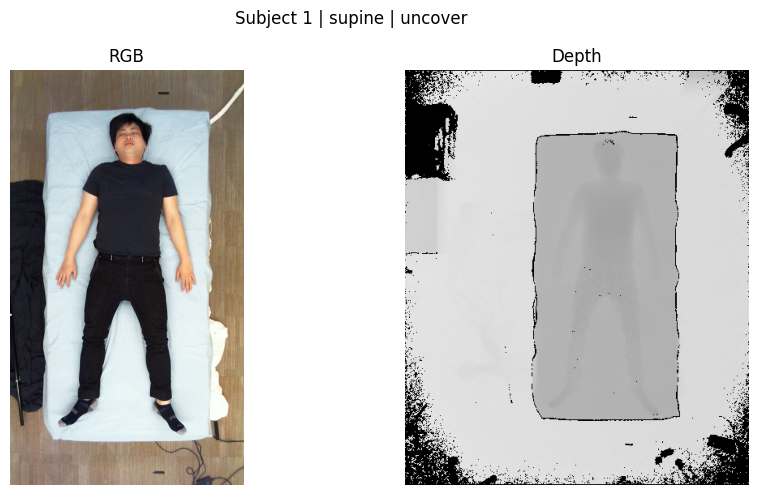

In [25]:
subject_id = df['subject_id'].unique()[0]
condition  = 'uncover'
label      = df['label'].unique()[0]

row_rgb   = df[(df['modality'] == 'rgb')   & (df['subject_id'] == subject_id) & (df['condition'] == condition) & (df['label'] == label)].iloc[0]
row_depth = df[(df['modality'] == 'depth') & (df['subject_id'] == subject_id) & (df['condition'] == condition) & (df['label'] == label)].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle(f'Subject {subject_id} | {label} | {condition}', fontsize=12)

axes[0].imshow(Image.open(DATASET_ROOT / row_rgb['image_path']).convert('RGB'))
axes[0].set_title('RGB')
axes[0].axis('off')

axes[1].imshow(Image.open(DATASET_ROOT / row_depth['image_path']).convert('L'), cmap='gray')
axes[1].set_title('Depth')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 9. Image Properties

In [26]:
# Check image sizes across modalities
for modality in ['rgb', 'depth']:
    sample_row = df[df['modality'] == modality].iloc[0]
    img = Image.open(DATASET_ROOT / sample_row['image_path'])
    arr = np.array(img)
    print(f"=== {modality.upper()} ===")
    print(f"  PIL size (W x H): {img.size}")
    print(f"  Array shape     : {arr.shape}")
    print(f"  dtype           : {arr.dtype}")
    print(f"  min / max       : {arr.min()} / {arr.max()}")
    print(f"  mean / std      : {arr.mean():.2f} / {arr.std():.2f}")
    print()

=== RGB ===
  PIL size (W x H): (576, 1024)
  Array shape     : (1024, 576, 3)
  dtype           : uint8
  min / max       : 0 / 255
  mean / std      : 136.53 / 78.15

=== DEPTH ===
  PIL size (W x H): (424, 512)
  Array shape     : (512, 424)
  dtype           : uint8
  min / max       : 0 / 255
  mean / std      : 187.58 / 64.34



## 10. Pixel Intensity Distribution

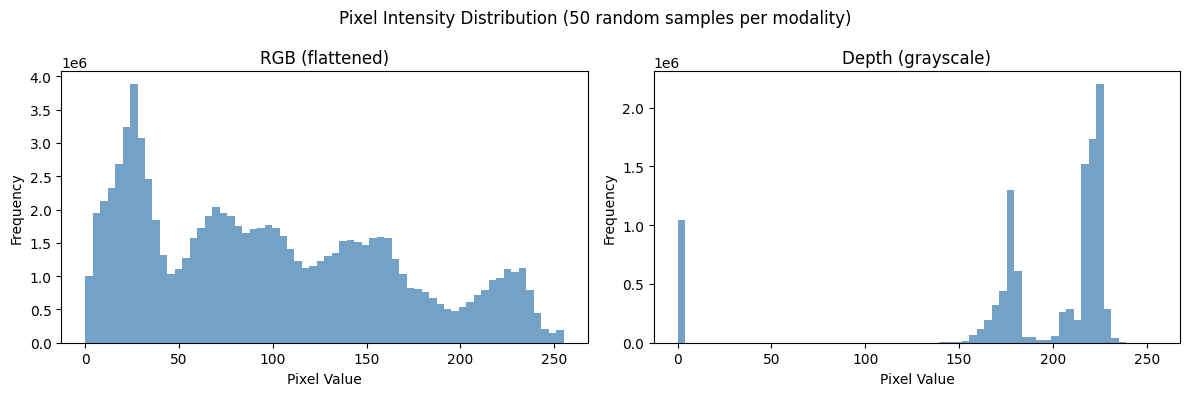

In [27]:
n_samples = 50
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Pixel Intensity Distribution ({n_samples} random samples per modality)')

for ax, modality, cmap_label in zip(axes, ['rgb', 'depth'], ['RGB (flattened)', 'Depth (grayscale)']):
    subset = df[df['modality'] == modality].sample(n=n_samples, random_state=42)
    pixels = []
    for _, row in subset.iterrows():
        img = np.array(Image.open(DATASET_ROOT / row['image_path']))
        pixels.append(img.flatten())
    pixels = np.concatenate(pixels)
    ax.hist(pixels, bins=64, color='steelblue', alpha=0.75)
    ax.set_title(cmap_label)
    ax.set_xlabel('Pixel Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 11. Summary

| Property | Value |
|---|---|
| Setting | danaLab |
| Subjects | 107 |
| Modalities | RGB, Depth |
| Posture Classes | supine, left, right |
| Cover Conditions | uncover, cover1, cover2 |
| Labels | From `posture_labels_all_modalities.csv` |

**Key observations:**
- Class distribution is balanced across all modalities and cover conditions
- Depth images retain body shape under cover occlusion where RGB may degrade
- All images are consistent in size across subjects